In [1]:
# Load and initialize the Gemini LLM model used for both reasoning and tool invocation.
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model = "gemini-2.5-flash-lite")

In [2]:
# Import the tool decorator used to register helper functions as callable tools.
from langchain.tools import tool

In [3]:
# Define a DuckDuckGo search tool that the agent can call for live web queries.
from langchain_community.tools import DuckDuckGoSearchRun
@tool
def duckduckgo_search(query:str):
    """This tool returns search results for an arbitrary internet query."""
    search = DuckDuckGoSearchRun()
    return search.invoke(query)

In [4]:
# Define a Wikipedia lookup tool for retrieving factual information from Wikipedia.
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

@tool
def wiki_tool(query:str):
    """This tool searches Wikipedia for topic-specific content."""
    wiki_search = WikipediaQueryRun(api_wrapper = WikipediaAPIWrapper())
    return wiki_search.invoke(query)

In [20]:
# Bind the tool functions to the LLM so it can route queries and receive observations.
tools = [duckduckgo_search,wiki_tool]

llm_with_tools = model.bind_tools(tools)

## **LangGraph Creation**
This section sets up the typed state schema and the nodes used by the ReAct agent: the LLM node for reasoning and the tool node for executing tool calls.

In [21]:
# Define the shared state schema for the graph as a typed structure.
from typing import TypedDict, List
from langchain_core.messages import BaseMessage
class graph_schema(TypedDict):
    messages: List

In [22]:
# Create the LLM node that builds the prompt, runs the tool-aware model, and appends the response.
from langchain_core.prompts import ChatPromptTemplate

def llm_node(state: graph_schema) -> graph_schema:
    
    messages = state['messages']

    # Prompt template for the LLM, including system instructions and the human input
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a helpful assistant that can use tools to answer questions."),
            ("human", "{input}")
        ]
    )

    # LLM With Tools 
    # llm_with_tools 

    chain = prompt | llm_with_tools 

    response = chain.invoke({"input": messages})

    # Update the state with the new message
    state['messages'] = messages + [response]

    return state

In [23]:
# Create the tool node that executes any tool calls emitted by the LLM and appends observations.
from langgraph.prebuilt import ToolNode
from langchain_core.messages import ToolMessage, HumanMessage

def tool_node(state: graph_schema) -> graph_schema:

    messages = state['messages']

    tools_by_name = {tool.name: tool for tool in tools}

    tool_results = []

    for tool_call in messages[-1].tool_calls:

        tool = tools_by_name[tool_call["name"]]

        observation = tool.invoke(tool_call["args"])

        tool_results.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))

    # Update the state with the tool results
    state['messages'] = messages + tool_results

    return state

## **Create a Condition node to select tool call**
This section builds the graph logic that decides whether the agent should invoke a tool or terminate after the LLM response.

In [24]:
# Determine whether the latest model output contains a tool call.
def if_tool_call(state: graph_schema) -> str:

    last_message = state['messages'][-1]

    if last_message.tool_calls:
        return "tool_node"
    else:
        return "end"

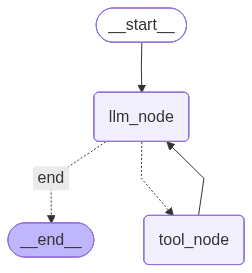

In [25]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

# Add nodes to the graph
graph.add_node("llm_node", llm_node)
graph.add_node("tool_node", tool_node)

# Add edges between nodes
graph.add_edge(START, "llm_node")
graph.add_conditional_edges("llm_node", if_tool_call,{"tool_node": "tool_node", "end": END})
graph.add_edge("tool_node", "llm_node")
graph.add_edge("llm_node", END)


react_graph = graph.compile()

from IPython.display import Image, display

# You could see the errors with the below command
Image(react_graph.get_graph().draw_mermaid_png())

### **Invoke Graph**
Run the compiled ReAct workflow with a human question so the agent can reason, optionally call tools, and return a response.

In [26]:
# Execute the graph with a single human message and obtain the agent's final output.
react_graph.invoke({"messages": HumanMessage(content = ["Who won the 2023 cricket World cup ?"])})

{'messages': ChatPromptTemplate(input_variables=[], input_types={}, partial_variables={}, messages=[HumanMessage(content=['Who won the 2023 cricket World cup ?'], additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'function_call': {'name': 'duckduckgo_search', 'arguments': '{"query": "Who won the 2023 cricket World cup ?"}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e3661-6f2a-78d0-b2a6-34ec0d3b2aad-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'Who won the 2023 cricket World cup ?'}, 'id': '785407c3-5af9-4c3f-97dd-f13d8fcd0e01', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 124, 'output_tokens': 28, 'total_tokens': 152, 'input_token_details': {'cache_read': 0}}), ToolMessage(content="The 2023 Cricket World Cup Final was a One Day International cricket match played at the Narendra Modi Sta